What is LangGraph?
LangGraph is a low-level orchestration framework for building stateful, 
multi-agent applications. Think of it as a way to create workflows where 
each step (node) processes data and passes it to the next step.

Key Concepts:
1. State: Shared memory that all nodes can read from and write to
2. Nodes: Functions that do specific tasks (like process data)
3. Edges: Connections between nodes that define the flow

In [5]:
from typing import TypedDict

class SimpleState(TypedDict):
    input_text: str
    output_text: str


SimpleState(
    input_text="Hello, world!",
    output_text="Hi there!"
)

{'input_text': 'Hello, world!', 'output_text': 'Hi there!'}

In [ ]:
# custom node --> think like a function ( python functions)

def process_input(state: SimpleState) -> SimpleState:
    # Process the input text and generate output
    state["output_text"] = state["input_text"].upper()
    return state

def add_prefix(state:SimpleState):
    print("Current State [Prefix]", state)

    output = "Hey, i have added something here. " + state['output_text']
    return {'output_text': output}

def add_suffix(state:SimpleState):

    print("Current State [Suffix]", state)

    output = state["output_text"] + ". i have added suffix!"

    return {'output_text': output}

In [9]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(SimpleState)
builder.add_node("process_input", process_input)
builder.add_node("add_prefix", add_prefix)
builder.add_node("add_suffix", add_suffix)

builder.add_edge(START, "process_input")
builder.add_edge("process_input", "add_prefix")
builder.add_edge("add_prefix", "add_suffix")
builder.add_edge("add_suffix", END)

graph = builder.compile()


/Users/rahultiwari/Documents/02_Freelancing/coding_ninja_fresh/dummy-env/lib/python3.13/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


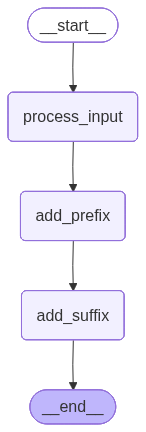

In [10]:
graph

In [11]:
initial_state= {'input_text': "hello"}

graph.invoke(initial_state)

Current State [Prefix] {'input_text': 'hello', 'output_text': 'HELLO'}
Current State [Suffix] {'input_text': 'hello', 'output_text': 'Hey, i have added something here. HELLO'}


{'input_text': 'hello',
 'output_text': 'Hey, i have added something here. HELLO. i have added suffix!'}

In [ ]:
# {'input_text': 'hello',
#  'output_text': 'Hey, i have added something here. HELLO. i have added suffix!'}

In [7]:
state = {'input_text': 'hello', 'output_text': ''}
process_input(state)

{'input_text': 'hello', 'output_text': 'HELLO'}